In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import glob

In [2]:
# view all columns of pandas
pd.set_option('display.max_columns', None)

In [3]:
list_files_merge = glob.glob('../data/desercion/merge/*_20*S.csv')

In [4]:
dtype_spec = {
    14: str,   # Columna 14 como string
    29: str,   # Columna 29 como string
    30: str,
    31: str,
    37: str,   # Columna 37 como string
    51: str,    # Columna 51 como string
    70: str,    # Columna 70 como string
    150: str,
    152: str,
    153: str,
    154: str,
    155: str,
    156: str,
    157: str,
    158: str,
}

df_merge = pd.DataFrame()
for file in list_files_merge:
    print("Cargando archivo:", file)
    df_tmp = pd.read_csv(file, dtype=dtype_spec, low_memory=False)
    print("Tamaño del DataFrame cargado:", df_tmp.shape[0])
    if "ESTACOMPLETA" in df_tmp.columns:
        print("Se descartaran", df_tmp["ESTACOMPLETA"].isnull().sum())
        df_tmp = df_tmp[~df_tmp["ESTACOMPLETA"].isnull()].copy()
        print("Tamaño del DataFrame filtrado:", df_tmp.shape[0])
        
        df_tmp["NUMEROSFAMILIARES"] = df_tmp["NUMEROSFAMILIARES"].astype(int)
    df_merge = pd.concat([df_merge, df_tmp], ignore_index=True)


Cargando archivo: ../data/desercion/merge\materias_dificultad_historico_desercion_2020_1S.csv
Tamaño del DataFrame cargado: 9466
Cargando archivo: ../data/desercion/merge\materias_dificultad_historico_desercion_2020_2S.csv
Tamaño del DataFrame cargado: 9105
Cargando archivo: ../data/desercion/merge\materias_dificultad_historico_desercion_2021_1S.csv
Tamaño del DataFrame cargado: 8753
Cargando archivo: ../data/desercion/merge\materias_dificultad_historico_desercion_2021_2S.csv
Tamaño del DataFrame cargado: 8368
Cargando archivo: ../data/desercion/merge\materias_dificultad_historico_desercion_2022_1S.csv
Tamaño del DataFrame cargado: 8190
Cargando archivo: ../data/desercion/merge\materias_dificultad_historico_desercion_2022_2S.csv
Tamaño del DataFrame cargado: 8039
Cargando archivo: ../data/desercion/merge\materias_dificultad_historico_desercion_2023_1S.csv
Tamaño del DataFrame cargado: 8087
Cargando archivo: ../data/desercion/merge\materias_dificultad_historico_desercion_2023_2S.csv
Tam

In [5]:
df_merge.to_csv('../data/desercion/merge/desercion_analisis.csv', index=False)

In [6]:
# Identificar columnas con tipos mixtos después de cargar
for col in df_merge.columns:
    unique_types = df_merge[col].apply(type).unique()
    if len(unique_types) > 1:
        print(f"Columna '{col}' (índice {df_merge.columns.get_loc(col)}): {unique_types}")
        print(f"  Ejemplos: {df_merge[col].dropna().head(5).tolist()}")
        print("-" * 60)

In [7]:
df_merge.shape

(68005, 27)

In [8]:
df_merge.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 68005 entries, 0 to 68004
Data columns (total 27 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   COD_ESTUDIANTE         68005 non-null  int64  
 1   ANIO                   68005 non-null  int64  
 2   TERMINO                68005 non-null  object 
 3   IDPERIODO              68005 non-null  int64  
 4   CANT_MATERIAS          68005 non-null  int64  
 5   CANT_VEZ_1             68005 non-null  int64  
 6   CANT_VEZ_2             68005 non-null  int64  
 7   CANT_VEZ_3             68005 non-null  int64  
 8   COMPLEMENTARIA         68005 non-null  object 
 9   MATERIA_INTEGRADORA    68005 non-null  object 
 10  PAIS                   68005 non-null  float64
 11  PROVINCIA              68005 non-null  object 
 12  CANTON                 68005 non-null  object 
 13  PENSION                68005 non-null  float64
 14  TIPOCOLEGIO            68005 non-null  object 
 15  MA

In [9]:
df_merge.describe()

,COD_ESTUDIANTE,ANIO,IDPERIODO,CANT_MATERIAS,CANT_VEZ_1,CANT_VEZ_2,CANT_VEZ_3,PAIS,PENSION,CANT_DIFICULTAD_ALTA,CANT_DIFICULTAD_MEDIA,CANT_DIFICULTAD_BAJA,PROMEDIO_GENERAL,MAT_TOMADAS,PROMEDIO_AP,MAT_TOMADAS_2V,MAT_TOMADAS_3V,MAT_REPROBADAS
count,6.800500e+04,68005.000000,68005.000000,68005.000000,68005.000000,68005.000000,68005.000000,68005.000000,68005.000000,68005.000000,68005.000000,68005.000000,68005.000000,68005.000000,68005.000000,68005.000000,68005.000000,68005.000000
mean,2.018249e+08,2021.438585,582.427836,4.180678,3.891317,0.245070,0.044291,122.898192,122.898192,0.239806,3.475318,0.465554,5.893267,32.627072,5.453887,2.315036,0.331784,4.253820
std,3.114433e+05,1.124916,5.634129,1.481693,1.689197,0.574409,0.236903,135.970578,135.970578,0.563027,1.560147,0.725486,1.152078,21.287890,2.046357,3.327511,0.920562,5.821212
min,1.988024e+08,2020.000000,574.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.017013e+08,2020.000000,575.000000,4.000000,3.000000,0.000000,0.000000,0.720000,0.720000,0.000000,3.000000,0.000000,5.270000,15.000000,5.110000,0.000000,0.000000,0.000000
50%,2.019026e+08,2021.000000,582.000000,4.000000,4.000000,0.000000,0.000000,89.430000,89.430000,0.000000,4.000000,0.000000,6.020000,31.000000,6.110000,1.000000,0.000000,2.000000
75%,2.020094e+08,2022.000000,586.000000,5.000000,5.000000,0.000000,0.000000,196.950000,196.950000,0.000000,5.000000,1.000000,6.680000,48.000000,6.710000,3.000000,0.000000,6.000000
max,2.023500e+08,2023.000000,590.000000,14.000000,14.000000,5.000000,3.000000,766.800000,766.800000,3.000000,13.000000,6.000000,10.000000,126.000000,9.640000,35.000000,18.000000,66.000000


In [10]:
df_merge

,COD_ESTUDIANTE,ANIO,TERMINO,IDPERIODO,CANT_MATERIAS,CANT_VEZ_1,CANT_VEZ_2,CANT_VEZ_3,COMPLEMENTARIA,MATERIA_INTEGRADORA,PAIS,PROVINCIA,CANTON,PENSION,TIPOCOLEGIO,MATERIA,CANT_DIFICULTAD_ALTA,CANT_DIFICULTAD_MEDIA,CANT_DIFICULTAD_BAJA,PROMEDIO_GENERAL,MAT_TOMADAS,PROMEDIO_AP,ESNOVATO,MAT_TOMADAS_2V,MAT_TOMADAS_3V,MAT_REPROBADAS,desercion
0,198802423,2020,1s,574,1,1,0,0,n,ap,0.00,guayas,guayaquil,0.00,fiscal,materia integradora de acuicultura,0,0,1,7.05,51.0,7.30,n,1.0,0.0,3.0,no
1,198901423,2020,1s,574,3,3,0,0,s,n,26.00,guayas,guayaquil,26.00,instituto,cálculo vectorial,0,3,0,6.29,61.0,6.82,n,8.0,0.0,11.0,no
2,198905267,2020,1s,574,1,1,0,0,n,ap,117.46,santa elena,salinas,117.46,particular,materia integradora de acuicultura,0,0,1,6.43,54.0,6.74,n,7.0,2.0,9.0,no
3,199202169,2020,1s,574,1,1,0,0,n,ap,0.72,guayas,guayaquil,0.72,nacional,materia integradora de economía,0,1,0,5.97,86.0,7.24,n,11.0,0.0,20.0,no
4,199500075,2020,1s,574,1,1,0,0,n,rp,150.00,guayas,guayaquil,150.00,particular,materia integradora de economía,0,1,0,6.27,71.0,7.07,n,12.0,2.0,19.0,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
68000,202319000,2023,2s,590,4,4,0,0,s,n,0.00,guayas,guayaquil,0.00,fiscal,cálculo de una variable,1,3,0,5.48,0.0,0.00,s,0.0,0.0,0.0,no
68001,202319018,2023,2s,590,4,4,0,0,s,n,80.00,guayas,guayaquil,80.00,particular,cálculo de una variable,2,2,0,5.70,0.0,0.00,s,0.0,0.0,0.0,si
68002,202319026,2023,2s,590,4,4,0,0,s,n,64.20,guayas,guayaquil,64.20,particular,cálculo de una variable,1,3,0,6.50,0.0,0.00,s,0.0,0.0,0.0,no
68003,202319034,2023,2s,590,7,7,0,0,n,n,40.00,distrito capital,caracas,40.00,particular,análisis y resolución de problemas,0,7,0,4.10,0.0,0.00,s,0.0,0.0,0.0,no


In [11]:
# show TERMINO in ANIO groupby
df_merge.groupby('ANIO')['TERMINO'].value_counts()

ANIO  TERMINO
2020  1s         9466
      2s         9105
2021  1s         8753
      2s         8368
2022  1s         8190
      2s         8039
2023  1s         8087
      2s         7997
Name: count, dtype: int64

In [12]:
# # show desercion in TERMINO with ANIO groupby 
# df_merge.groupby(['TERMINO', 'ANIO'])['desercion'].value_counts().unstack(fill_value=0)

# show desercion in TERMINO with ANIO groupby 
# pd.crosstab([df_merge['TERMINO'], df_merge['ANIO']], df_merge['desercion'], margins=True, margins_name='Total')
pd.crosstab([df_merge['ANIO']], df_merge['desercion'], margins=True, margins_name='Total')

# # show desercion in TERMINO with ANIO groupby 
# display(df_merge.groupby(['ANIO', 'TERMINO', 'desercion']).size().unstack(fill_value=0))

desercion,no,si,Total
ANIO,,,
2020,18142,429,18571
2021,16513,608,17121
2022,15582,647,16229
2023,15470,614,16084
Total,65707,2298,68005


In [13]:
df_merge["desercion"].value_counts()

desercion
no    65707
si     2298
Name: count, dtype: int64

In [15]:
if "APELLIDOS" in df_merge.columns:
    df_merge[df_merge["APELLIDOS"].isnull()].shape, df_merge[df_merge["CODESTUDIANTE"].isnull()].shape

In [16]:
"Materia integradora", df_merge[df_merge["MATERIA_INTEGRADORA"].isnull()].shape, "Cantidad de veces", df_merge[df_merge["CANT_VEZ_2"].isnull()].shape[0], df_merge[df_merge["CANT_VEZ_3"].isnull()].shape[0], "Completo", df_merge.shape

('Materia integradora',
 (0, 27),
 'Cantidad de veces',
 0,
 0,
 'Completo',
 (68005, 27))

In [18]:
if "APELLIDOS" in df_merge.columns:
    df_merge["NUMEROSFAMILIARES"].value_counts()

In [20]:
if "APELLIDOS" in df_merge.columns:
    df_merge["SEXO"].value_counts()

## Análisis exploratorio orientado a la deserción
Este bloque cubre cuatro frentes clave antes de entrenar modelos: (1) balance de la variable objetivo, (2) calidad y completitud de los datos, (3) comportamiento de variables numéricas relevantes y su relación con `desercion`, y (4) interacciones de variables categóricas con la etiqueta.

In [21]:
numeric_candidates = [
    "CANT_DIFICULTAD_BAJA",
    "CANT_DIFICULTAD_MEDIA",
    "CANT_DIFICULTAD_ALTA",
    "PROMEDIO_GENERAL",
    "MAT_TOMADAS",
    "PROMEDIO_AP",
    "MAT_TOMADAS_2V",
    "MAT_TOMADAS_3V",
    "MAT_REPROBADAS",
    "NUMEROSFAMILIARES"
]

cat_candidates = [
    "OTROSIDIOMAS",
    "TIPOCOLEGIO"
]

# Filtrar solo las columnas que realmente existen en df_merge
numeric_cols = [c for c in numeric_candidates if c in df_merge.columns]
cat_cols    = [c for c in cat_candidates    if c in df_merge.columns]

# Asegurarnos de que exista la columna 'desercion'
if "desercion" not in df_merge.columns:
    raise ValueError("La columna 'desercion' no existe en df_merge.")

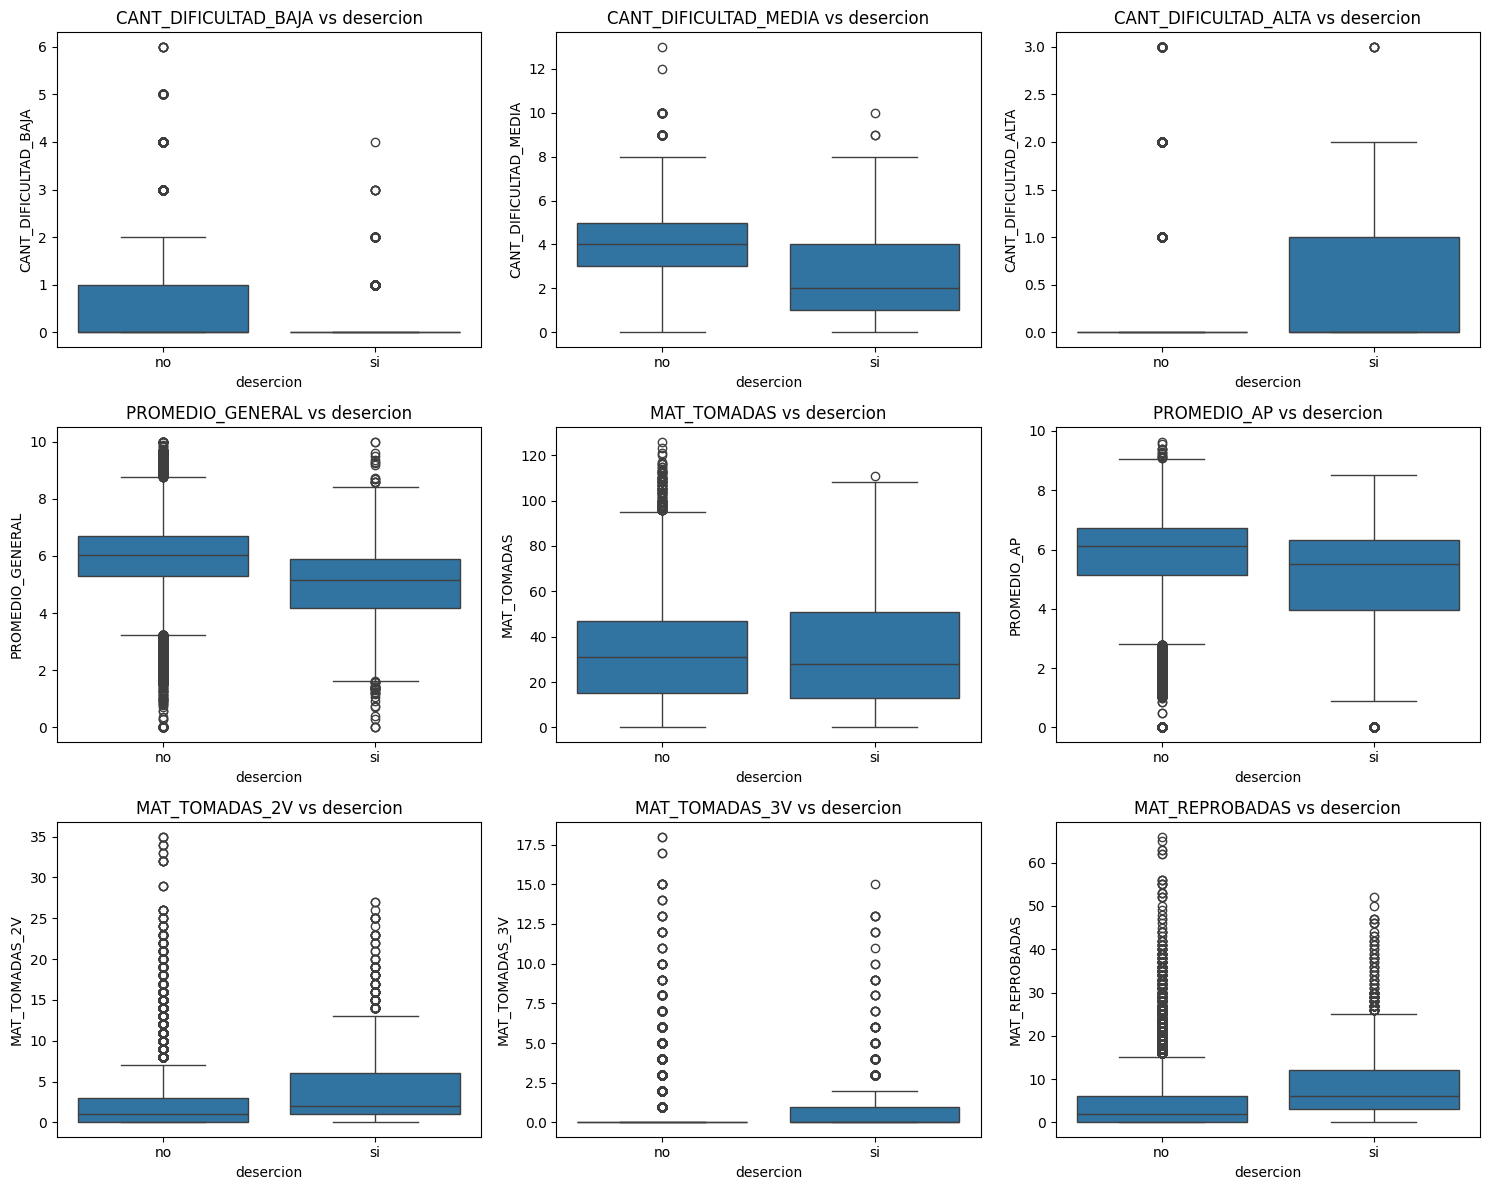

In [22]:
# ==========================
# 1. BOXPLOTS por desercion
# ==========================
if numeric_cols:
    n = len(numeric_cols)
    ncols = 3
    nrows = (n + ncols - 1) // ncols

    plt.figure(figsize=(5 * ncols, 4 * nrows))
    for i, col in enumerate(numeric_cols, 1):
        plt.subplot(nrows, ncols, i)
        sns.boxplot(
            data=df_merge,
            x="desercion",
            y=col
        )
        plt.title(f"{col} vs desercion")
    plt.tight_layout()
    plt.show()

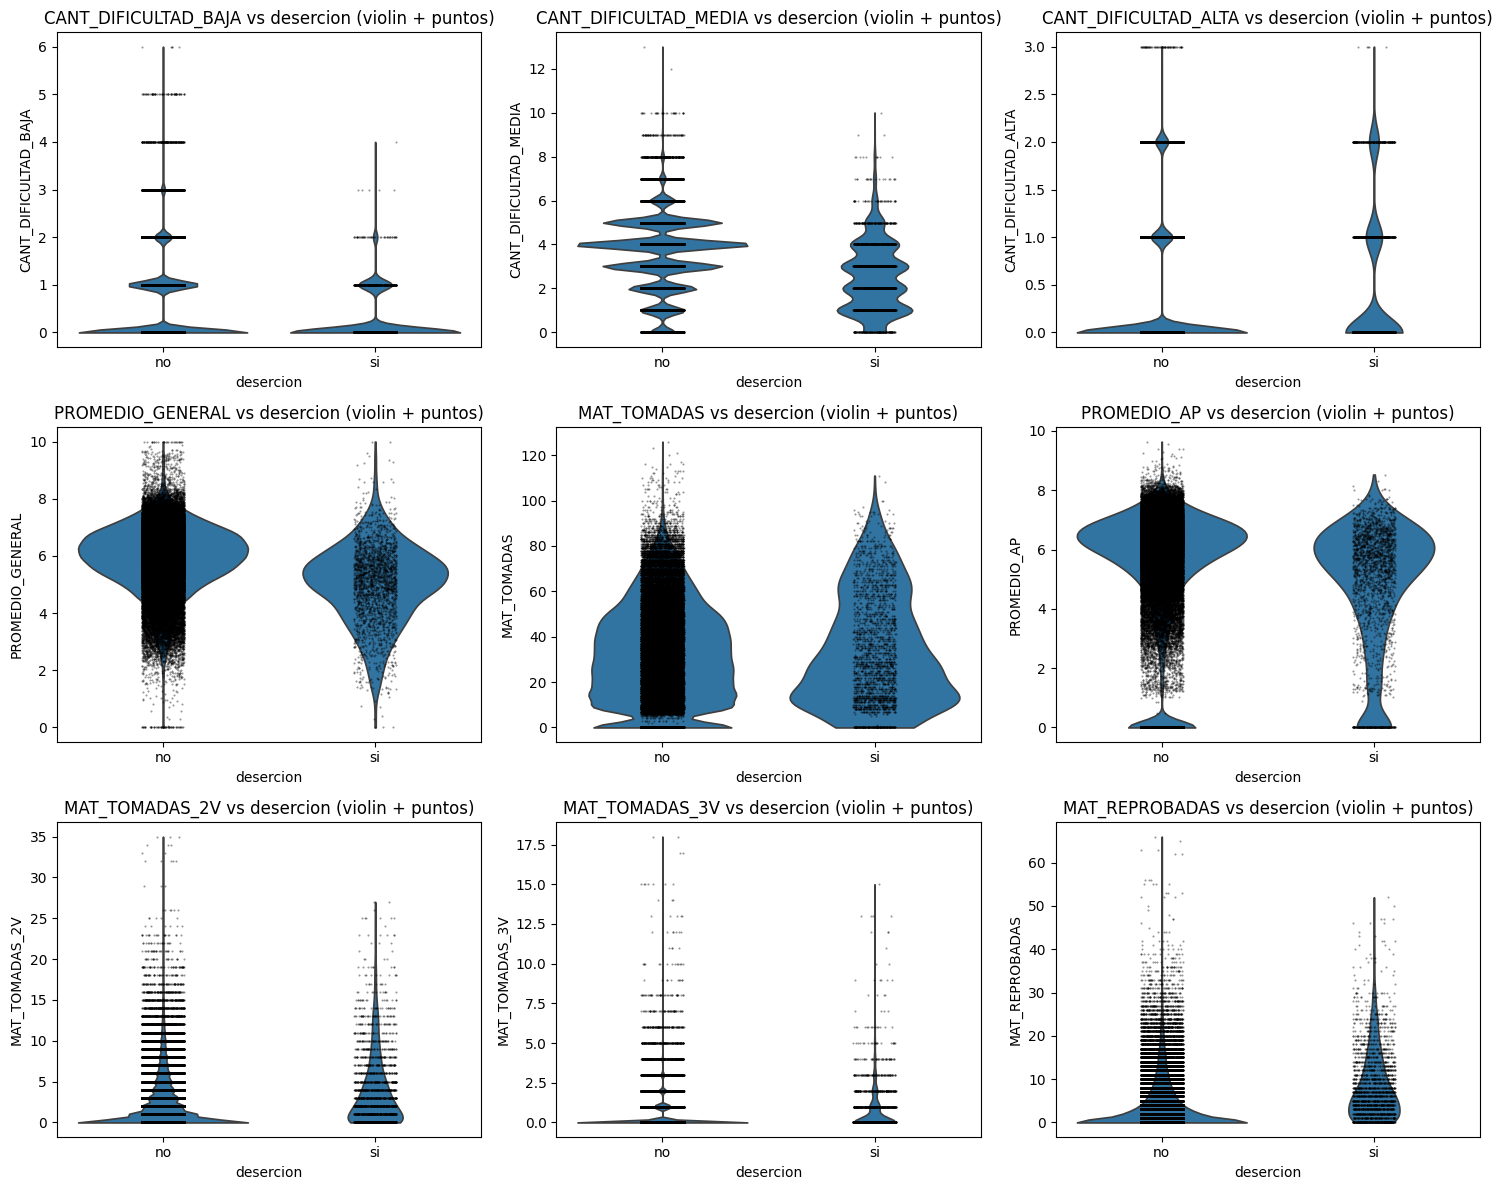

In [23]:
# ===================================
# 2. VIOLIN + STRIP (mismo objetivo)
# ===================================
if numeric_cols:
    n = len(numeric_cols)
    ncols = 3
    nrows = (n + ncols - 1) // ncols

    plt.figure(figsize=(5 * ncols, 4 * nrows))
    for i, col in enumerate(numeric_cols, 1):
        plt.subplot(nrows, ncols, i)
        sns.violinplot(
            data=df_merge,
            x="desercion",
            y=col,
            inner=None,
            cut=0
        )
        sns.stripplot(
            data=df_merge,
            x="desercion",
            y=col,
            color="black",
            size=1.5,
            alpha=0.4
        )
        plt.title(f"{col} vs desercion (violin + puntos)")
    plt.tight_layout()
    plt.show()

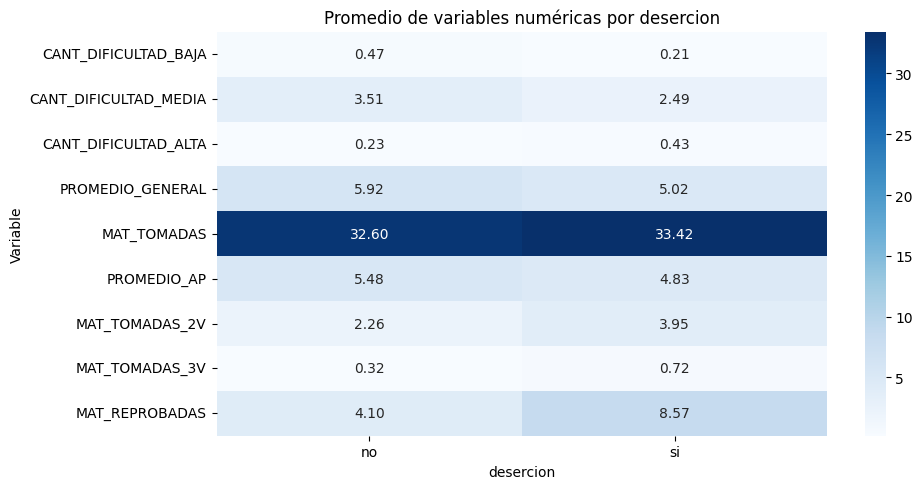

In [24]:
# ==========================================
# 3. BARRAS: promedio por desercion (num)
# ==========================================
if numeric_cols:
    plt.figure(figsize=(10, 5))
    mean_by_desercion = df_merge.groupby("desercion")[numeric_cols].mean().T
    sns.heatmap(
        mean_by_desercion,
        annot=True,
        fmt=".2f",
        cmap="Blues"
    )
    plt.title("Promedio de variables numéricas por desercion")
    plt.ylabel("Variable")
    plt.xlabel("desercion")
    plt.tight_layout()
    plt.show()

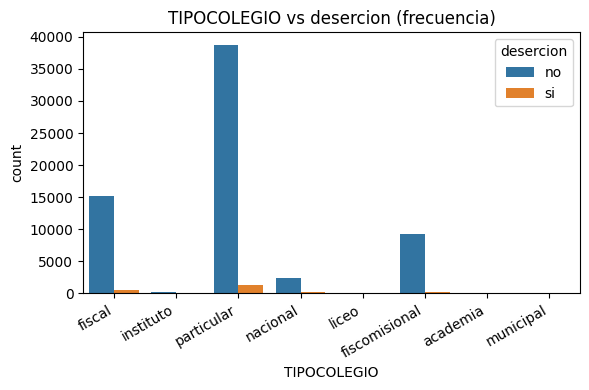

In [25]:
# ==================================================
# 4. Gráficos de barras para variables categóricas
#    (OTROSIDIOMAS, TIPOCOLEGIO) vs desercion
# ==================================================
for col in cat_cols:
    plt.figure(figsize=(6, 4))
    sns.countplot(
        data=df_merge,
        x=col,
        hue="desercion"
    )
    plt.title(f"{col} vs desercion (frecuencia)")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()

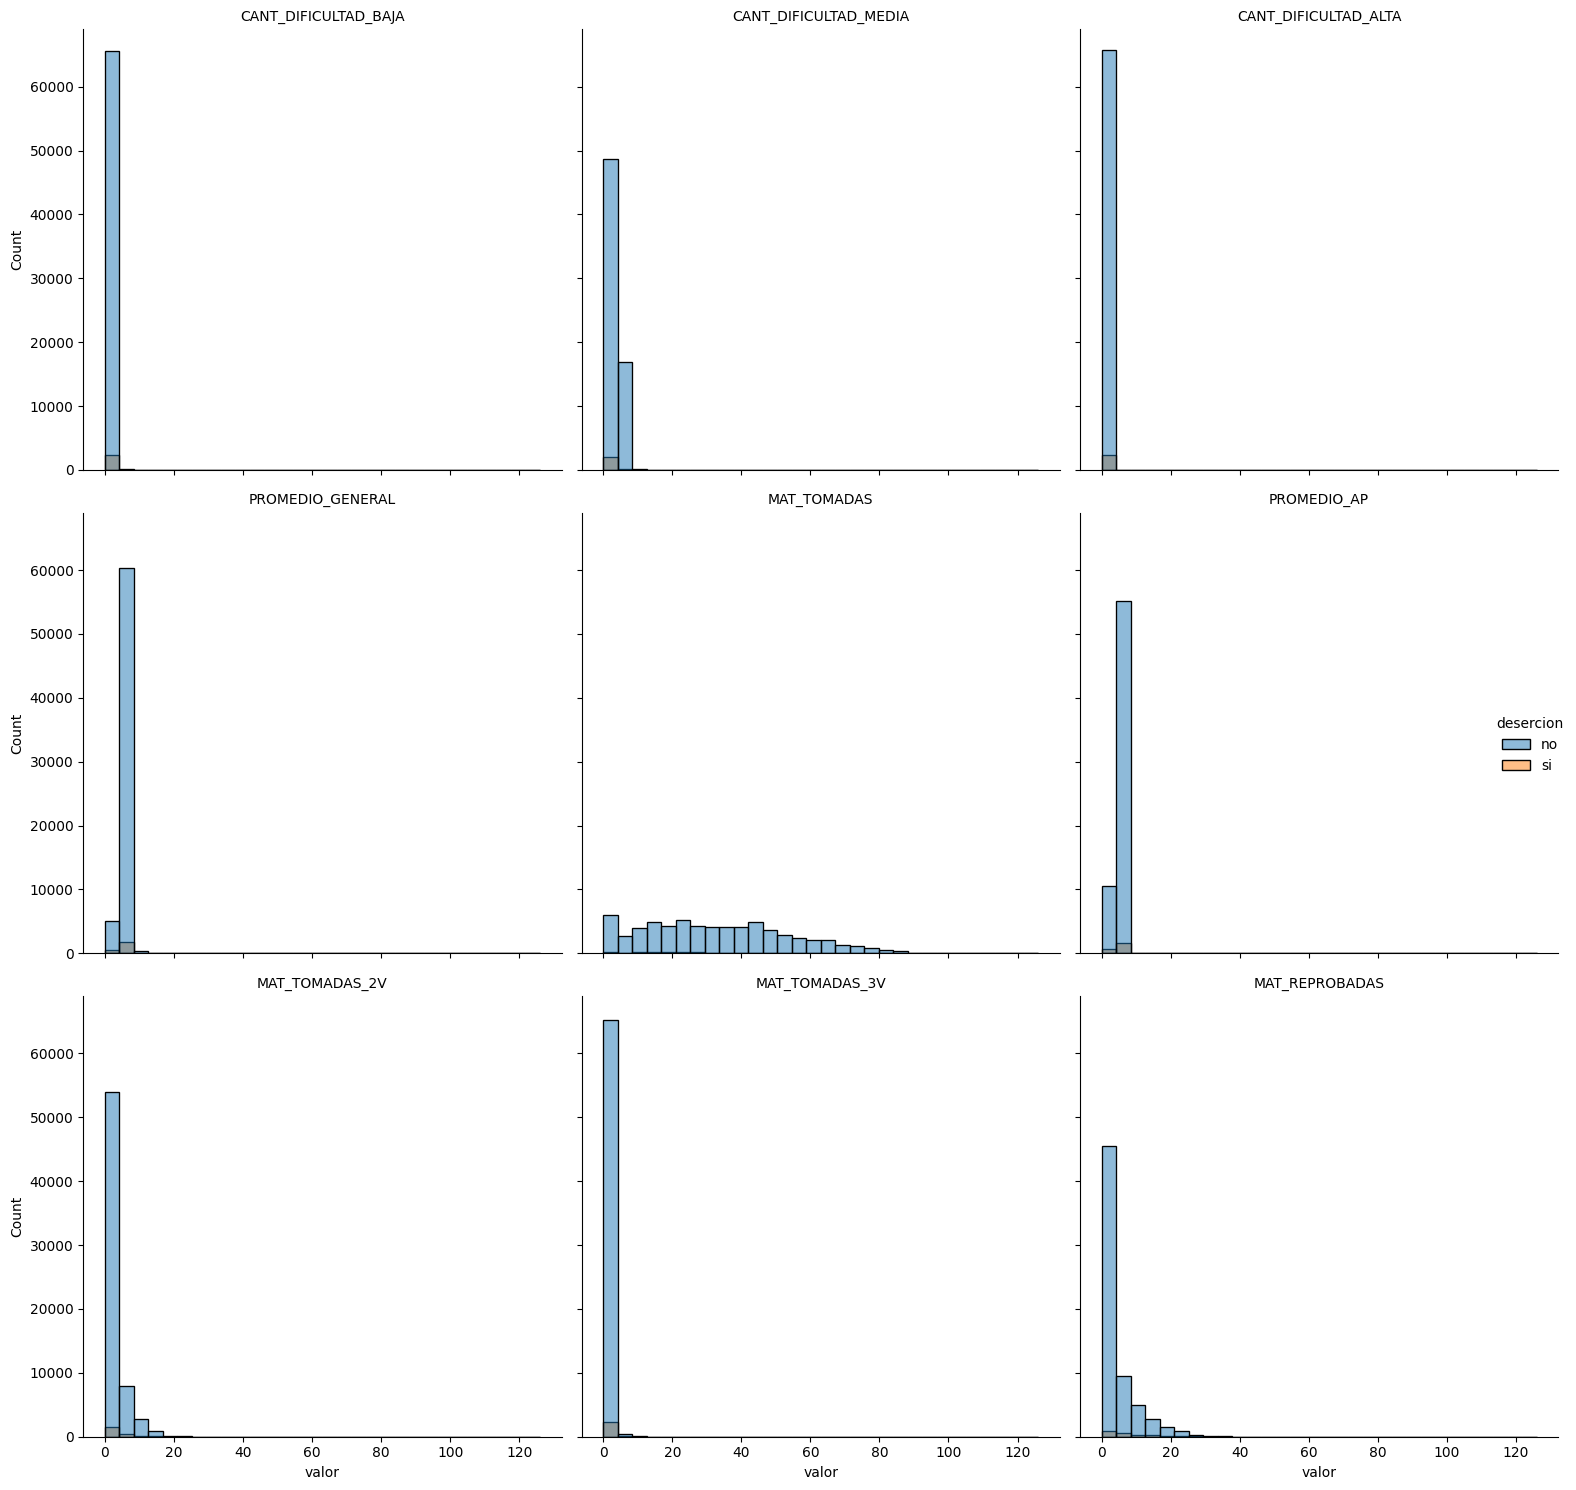

In [26]:
# ==========================================
# 5. FacetGrid para una visión más global
#    (solo numéricas, transformando a largo)
# ==========================================
if numeric_cols:
    # Preparamos un DF en formato largo
    long_df = df_merge[["desercion"] + numeric_cols].melt(
        id_vars="desercion",
        var_name="variable",
        value_name="valor"
    )

    g = sns.displot(
        data=long_df,
        x="valor",
        col="variable",
        hue="desercion",
        col_wrap=3,
        kind="hist",
        bins=30,
        common_norm=False,
        facet_kws={"margin_titles": True}
    )
    g.set_titles("{col_name}")
    plt.tight_layout()
    plt.show()

## Análisis

In [27]:
# Diagnóstico general del dataset y balance de la etiqueta
dataset_overview = pd.Series({
    "filas": df_merge.shape[0],
    "columnas": df_merge.shape[1],
    "anios_unicos": df_merge['ANIO'].nunique() if 'ANIO' in df_merge.columns else None,
    "terminos_unicos": df_merge['TERMINO'].nunique() if 'TERMINO' in df_merge.columns else None
}, name="panorama_dataset")
display(dataset_overview)

target_counts = df_merge['desercion'].value_counts(dropna=False).rename('conteo')
target_pct = df_merge['desercion'].value_counts(normalize=True, dropna=False).mul(100).round(2).rename('porc')
display(pd.concat([target_counts, target_pct], axis=1))

if 'ANIO' in df_merge.columns:
    display(df_merge.groupby(['ANIO', 'desercion']).size().unstack(fill_value=0))

if 'TERMINO' in df_merge.columns:
    display(df_merge.groupby(['TERMINO', 'desercion']).size().unstack(fill_value=0))

filas              68005
columnas              27
anios_unicos           4
terminos_unicos        2
Name: panorama_dataset, dtype: int64

,conteo,porc
desercion,,
no,65707,96.62
si,2298,3.38


desercion,no,si
ANIO,,
2020,18142,429
2021,16513,608
2022,15582,647
2023,15470,614


desercion,no,si
TERMINO,,
1s,33453,1043
2s,32254,1255


In [28]:
# Calidad de datos: valores perdidos y duplicados
missing_pct = df_merge.isna().mean().mul(100).sort_values(ascending=False)
missing_table = missing_pct[missing_pct > 0].round(2).to_frame(name="porc_missing")
display(missing_table.head(25))

dup_cols = [col for col in ['CODESTUDIANTE', 'ANIO', 'TERMINO'] if col in df_merge.columns]
duplicated_rows = df_merge.duplicated(subset=dup_cols).sum() if dup_cols else df_merge.duplicated().sum()
print(f"Filas duplicadas considerando {dup_cols if dup_cols else 'todas las columnas'}: {duplicated_rows}")

high_missing = missing_table[missing_table['porc_missing'] > 30]
if not high_missing.empty:
    print("Variables con más de 30% de valores faltantes, candidatas a imputación o descarte:")
    display(high_missing)

,porc_missing


Filas duplicadas considerando ['ANIO', 'TERMINO']: 67997


,count,mean,std,min,25%,50%,75%,max,iqr
COD_ESTUDIANTE,68005.0,2.018249e+08,311443.274321,198802423.0,2.017013e+08,2.019026e+08,2.020094e+08,2.023500e+08,308080.00
PENSION,68005.0,1.228982e+02,135.970578,0.0,7.200000e-01,8.943000e+01,1.969500e+02,7.668000e+02,196.23
PAIS,68005.0,1.228982e+02,135.970578,0.0,7.200000e-01,8.943000e+01,1.969500e+02,7.668000e+02,196.23
MAT_TOMADAS,68005.0,3.262707e+01,21.287890,0.0,1.500000e+01,3.100000e+01,4.800000e+01,1.260000e+02,33.00
MAT_REPROBADAS,68005.0,4.253820e+00,5.821212,0.0,0.000000e+00,2.000000e+00,6.000000e+00,6.600000e+01,6.00
IDPERIODO,68005.0,5.824278e+02,5.634129,574.0,5.750000e+02,5.820000e+02,5.860000e+02,5.900000e+02,11.00
MAT_TOMADAS_2V,68005.0,2.315036e+00,3.327511,0.0,0.000000e+00,1.000000e+00,3.000000e+00,3.500000e+01,3.00
PROMEDIO_AP,68005.0,5.453887e+00,2.046357,0.0,5.110000e+00,6.110000e+00,6.710000e+00,9.640000e+00,1.60
CANT_VEZ_1,68005.0,3.891317e+00,1.689197,0.0,3.000000e+00,4.000000e+00,5.000000e+00,1.400000e+01,2.00
CANT_DIFICULTAD_MEDIA,68005.0,3.475318e+00,1.560147,0.0,3.000000e+00,4.000000e+00,5.000000e+00,1.300000e+01,2.00


desercion                               no            si
ANIO                  mean    2.021432e+03  2.021629e+03
                      median  2.021000e+03  2.022000e+03
                      std     1.126264e+00  1.068428e+00
CANT_DIFICULTAD_ALTA  mean    2.330193e-01  4.338555e-01
                      median  0.000000e+00  0.000000e+00
                      std     5.563715e-01  7.009062e-01
CANT_DIFICULTAD_BAJA  mean    4.744852e-01  2.101828e-01
                      median  0.000000e+00  0.000000e+00
                      std     7.310963e-01  4.746429e-01
CANT_DIFICULTAD_MEDIA mean    3.509778e+00  2.489991e+00
                      median  4.000000e+00  2.000000e+00
                      std     1.548712e+00  1.564221e+00
CANT_MATERIAS         mean    4.217283e+00  3.134030e+00
                      median  4.000000e+00  3.000000e+00
                      std     1.462697e+00  1.631578e+00
CANT_VEZ_1            mean    3.951527e+00  2.169713e+00
                      median  4.000000e+00  2.000000e+00
                      std     1.645160e+00  1.996494e+00
CANT_VEZ_2            mean    2.334454e-01  5.774587e-01
                      median  0.000000e+00  0.000000e+00
                      std     5.576685e-01  8.705285e-01
CANT_VEZ_3            mean    3.231010e-02  3.868581e-01
                      median  0.000000e+00  0.000000e+00
                      std     1.954652e-01  6.686861e-01
COD_ESTUDIANTE        mean    2.018286e+08  2.017187e+08
                      median  2.019026e+08  2.018750e+08
                      std     3.035590e+05  4.733532e+05
IDPERIODO             mean    5.823902e+02  5.835030e+02
                      median  5.820000e+02  5.850000e+02
                      std     5.644997e+00  5.201323e+00
MAT_REPROBADAS        mean    4.102774e+00  8.572672e+00
                      median  2.000000e+00  6.000000e+00
                      std     5.659739e+00  8.223012e+00
MAT_TOMADAS           mean    3.259946e+01  3.341645e+01
                      median  3.100000e+01  2.800000e+01
                      std     2.118026e+01  2.415523e+01
MAT_TOMADAS_2V        mean    2.257735e+00  3.953438e+00
                      median  1.000000e+00  2.000000e+00
                      std     3.261184e+00  4.560531e+00
MAT_TOMADAS_3V        mean    3.183375e-01  7.162750e-01
                      median  0.000000e+00  0.000000e+00
                      std     8.903814e-01  1.502720e+00
PAIS                  mean    1.234146e+02  1.081328e+02
                      median  9.000000e+01  6.700000e+01
                      std     1.361744e+02  1.291646e+02
PENSION               mean    1.234146e+02  1.081328e+02
                      median  9.000000e+01  6.700000e+01
                      std     1.361744e+02  1.291646e+02
PROMEDIO_AP           mean    5.475553e+00  4.834386e+00
                      median  6.130000e+00  5.510000e+00
                      std     2.041412e+00  2.090515e+00
PROMEDIO_GENERAL      mean    5.923683e+00  5.023581e+00
                      median  6.040000e+00  5.160000e+00
                      std     1.131828e+00  1.366641e+00

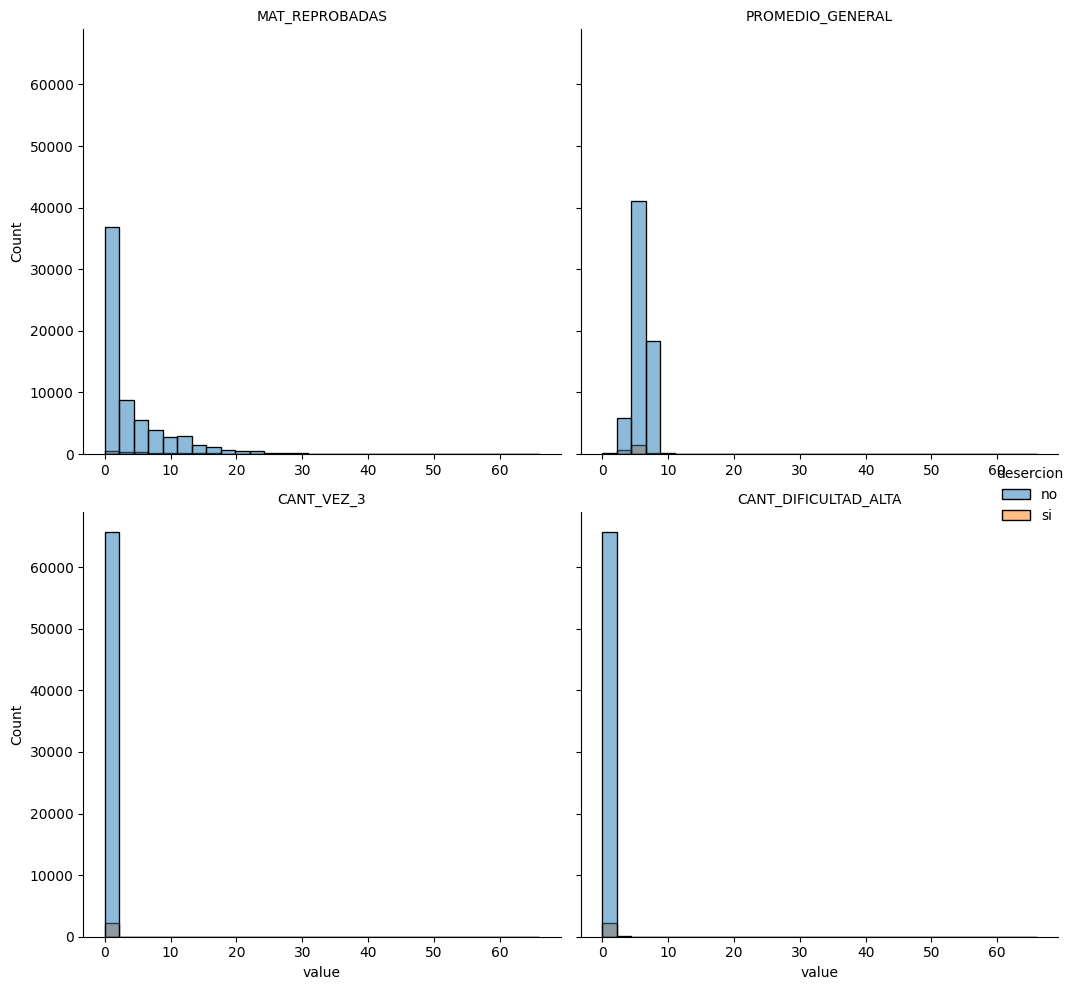

In [30]:
# Variables numéricas clave: estadísticos y comportamiento por etiqueta
numeric_candidates = [
    'CANT_MATERIAS','CANT_VEZ_1','CANT_VEZ_2','CANT_VEZ_3',
    'CANT_DIFICULTAD_BAJA','CANT_DIFICULTAD_MEDIA','CANT_DIFICULTAD_ALTA',
    'PROMEDIO_GENERAL','MAT_TOMADAS','PROMEDIO_AP','MAT_TOMADAS_2V',
    'MAT_TOMADAS_3V','MAT_REPROBADAS'
]
auto_numeric = df_merge.select_dtypes(include='number').columns.tolist()
numeric_features = [col for col in dict.fromkeys(numeric_candidates + auto_numeric) if col in df_merge.columns]

if numeric_features:
    df_numeric = df_merge[numeric_features].copy()
    describe_tbl = df_numeric.describe(percentiles=[0.25, 0.5, 0.75]).T
    describe_tbl['iqr'] = describe_tbl['75%'] - describe_tbl['25%']
    display(describe_tbl.sort_values(by='std', ascending=False).head(20))

    grouped_numeric = df_merge.groupby('desercion')[numeric_features].agg(['mean','median','std'])
    display(grouped_numeric.transpose().sort_index())

    plot_priority = [
        'MAT_REPROBADAS','PROMEDIO_GENERAL','CANT_VEZ_3','CANT_DIFICULTAD_ALTA','MAT_TOMADAS','PROMEDIO_AP'
    ]
    selected_for_plots = [col for col in plot_priority if col in numeric_features][:4]

    if selected_for_plots:
        # Incluir 'desercion' en el melt para poder usarlo como hue
        melted = df_merge[selected_for_plots + ['desercion']].melt(
            id_vars='desercion',
            var_name='feature', 
            value_name='value'
        )
        g = sns.displot(
            data=melted,
            x='value',
            col='feature',
            hue='desercion',
            col_wrap=2,
            facet_kws={'sharex': False, 'margin_titles': True},
            kind='hist',
            bins=30,
            common_norm=False
        )
        g.set_titles(col_template="{col_name}")
        plt.tight_layout()
        plt.show()
else:
    print("No se detectaron variables numéricas para analizar.")

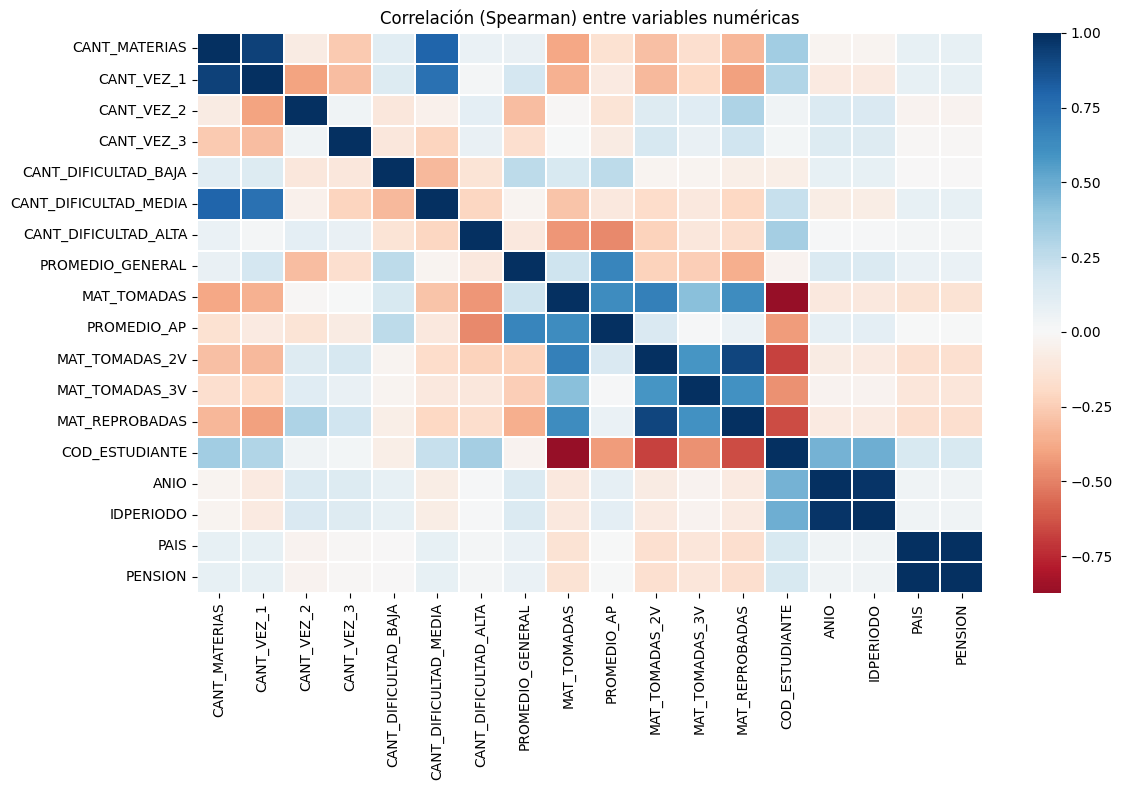

In [31]:
# Matriz de correlaciones (Spearman para robustez ante no normalidad)
if numeric_features and len(numeric_features) > 1:
    corr_matrix = df_merge[numeric_features].corr(method='spearman')
    plt.figure(figsize=(12, 8))
    sns.heatmap(corr_matrix, cmap='RdBu', center=0, annot=False, linewidths=0.3)
    plt.title('Correlación (Spearman) entre variables numéricas')
    plt.tight_layout()
    plt.show()
else:
    print("Se requieren al menos dos variables numéricas para calcular correlaciones.")

In [32]:
# Variables categóricas relevantes vs. deserción
categorical_candidates = [
    'MATERIA_INTEGRADORA','TIENEDISCAPACIDAD','SEXO','AUTOIDENTIFICACIONGENERO',
    'COLEGIO','TIPOCOLEGIO','REGION','ESTRATO','FINANCIACION'
 ]
object_cols = df_merge.select_dtypes(include=['object','category']).columns.tolist()
cat_features = [col for col in dict.fromkeys(categorical_candidates + object_cols) if col in df_merge.columns and col != 'desercion']

max_levels = 12
for col in cat_features:
    value_counts = df_merge[col].value_counts(dropna=False)
    cat_overview = pd.DataFrame({
        'conteo': value_counts,
        'porc': value_counts.div(len(df_merge)).mul(100).round(2)
    })
    display(cat_overview.head(max_levels))

    top_categories = value_counts.head(max_levels).index
    subset = df_merge[df_merge[col].isin(top_categories)]
    cross = pd.crosstab(subset[col], subset['desercion'], margins=False, normalize='index').round(3)
    display(cross)
    print('-' * 60)

,conteo,porc
MATERIA_INTEGRADORA,,
n,64320,94.58
ap,3490,5.13
rp,188,0.28
pf,7,0.01


desercion,no,si
MATERIA_INTEGRADORA,,
ap,1.000,0.000
n,0.965,0.035
pf,0.857,0.143
rp,0.835,0.165


------------------------------------------------------------


,conteo,porc
TIPOCOLEGIO,,
particular,40107,58.98
fiscal,15677,23.05
fiscomisional,9484,13.95
nacional,2507,3.69
instituto,171,0.25
liceo,31,0.05
municipal,23,0.03
academia,5,0.01


desercion,no,si
TIPOCOLEGIO,,
academia,1.000,0.000
fiscal,0.968,0.032
fiscomisional,0.970,0.030
instituto,0.959,0.041
liceo,1.000,0.000
municipal,1.000,0.000
nacional,0.935,0.065
particular,0.966,0.034


...

desercion,no,si
MATERIA,,
análisis financiero,0.979,0.021
análisis y resolución de problemas,0.955,0.045
arte y ciencia,0.961,0.039
comunicación,0.966,0.034
cálculo de una variable,0.928,0.072
cálculo vectorial,0.947,0.053
electricidad básica,0.976,0.024
emprendimiento e innovación,0.980,0.020
fundamentos de programación,0.954,0.046


------------------------------------------------------------


,conteo,porc
ESNOVATO,,
n,61917,91.05
s,6088,8.95


desercion,no,si
ESNOVATO,,
n,0.966,0.034
s,0.969,0.031


------------------------------------------------------------


### Próximos pasos sugeridos
- Revisar los histogramas para detectar outliers extremos en cargas académicas (ej. `MAT_TOMADAS_3V`, `MAT_REPROBADAS`) y definir reglas de winsorización o escalado robusto.
- A partir de la matriz de correlación, priorizar variables con mayor señal respecto a `desercion` y reducir multicolinealidad (p. ej., combinar conteos altamente correlacionados).
- En categóricas con muchas modalidades (como `COLEGIO` o `REGION`), evaluar agrupaciones basadas en riesgo promedio o usar codificación target/WOE tras aplicar smoothing.
- Confirmar consistencia temporal (ANIO/TERMINO) para evitar fuga de información al dividir en train/test.
- Preparar un diccionario de datos con reglas de imputación por variable antes del modelado supervisado.